In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [10]:
df = pd.read_csv("student_lifestyle_performance_dataset.csv")

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1000 non-null   int64  
 1   Branch                 1000 non-null   str    
 2   Study_Hours_per_Day    1000 non-null   float64
 3   Sleep_Hours            1000 non-null   float64
 4   Screen_Time_Hours      1000 non-null   float64
 5   Gym_Hours_per_Week     1000 non-null   float64
 6   Diet_Type              1000 non-null   str    
 7   Attendance_Percentage  1000 non-null   float64
 8   Stress_Level_1_to_10   1000 non-null   float64
 9   Residence              1000 non-null   str    
 10  Internal_Marks         1000 non-null   float64
 11  CGPA                   1000 non-null   float64
dtypes: float64(8), int64(1), str(3)
memory usage: 93.9 KB


In [5]:
df.head(8)

,Age,Branch,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Diet_Type,Attendance_Percentage,Stress_Level_1_to_10,Residence,Internal_Marks,CGPA
0,23,ECE,4.14,6.84,9.23,2.67,Non-Veg,81.24,4.93,Hosteller,65.86,7.52
1,20,Civil,5.97,5.52,3.09,15.61,Veg,90.55,6.96,Day Scholar,62.52,7.21
2,24,Electrical,3.19,3.39,5.02,2.52,Veg,69.40,7.38,Hosteller,40.11,4.84
3,21,CSE,4.77,6.44,9.21,0.00,Non-Veg,80.79,5.84,Day Scholar,61.25,6.74
4,23,Civil,5.42,6.54,4.76,9.93,Veg,82.63,6.67,Day Scholar,64.54,7.77
5,19,ECE,3.01,7.25,5.07,13.89,Non-Veg,80.43,3.28,Hosteller,64.40,7.26
6,23,ECE,2.77,6.24,1.66,8.00,Non-Veg,76.35,3.30,Day Scholar,57.73,6.87
7,24,CSE,3.77,4.71,3.94,9.44,Veg,76.02,4.66,Hosteller,60.32,7.04


In [6]:
df.describe()

,Age,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Attendance_Percentage,Stress_Level_1_to_10,Internal_Marks,CGPA
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.898000,4.037970,6.525030,4.95191,7.311910,80.084340,4.582850,65.922380,7.319300
std,2.603916,1.434691,1.205664,1.97294,4.949333,8.578242,2.024595,10.123247,0.953812
min,17.000000,0.500000,3.000000,1.00000,0.000000,54.660000,1.000000,35.000000,4.000000
25%,19.000000,3.020000,5.710000,3.49000,3.445000,74.307500,3.095000,59.330000,6.690000
50%,21.000000,4.090000,6.515000,4.95500,6.975000,80.210000,4.540000,65.600000,7.300000
75%,23.000000,5.030000,7.380000,6.37250,10.780000,86.165000,5.962500,72.547500,7.990000
max,25.000000,8.050000,10.000000,10.84000,21.000000,100.000000,10.000000,93.930000,10.000000


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isnull().sum()

Age                      0
Branch                   0
Study_Hours_per_Day      0
Sleep_Hours              0
Screen_Time_Hours        0
Gym_Hours_per_Week       0
Diet_Type                0
Attendance_Percentage    0
Stress_Level_1_to_10     0
Residence                0
Internal_Marks           0
CGPA                     0
dtype: int64

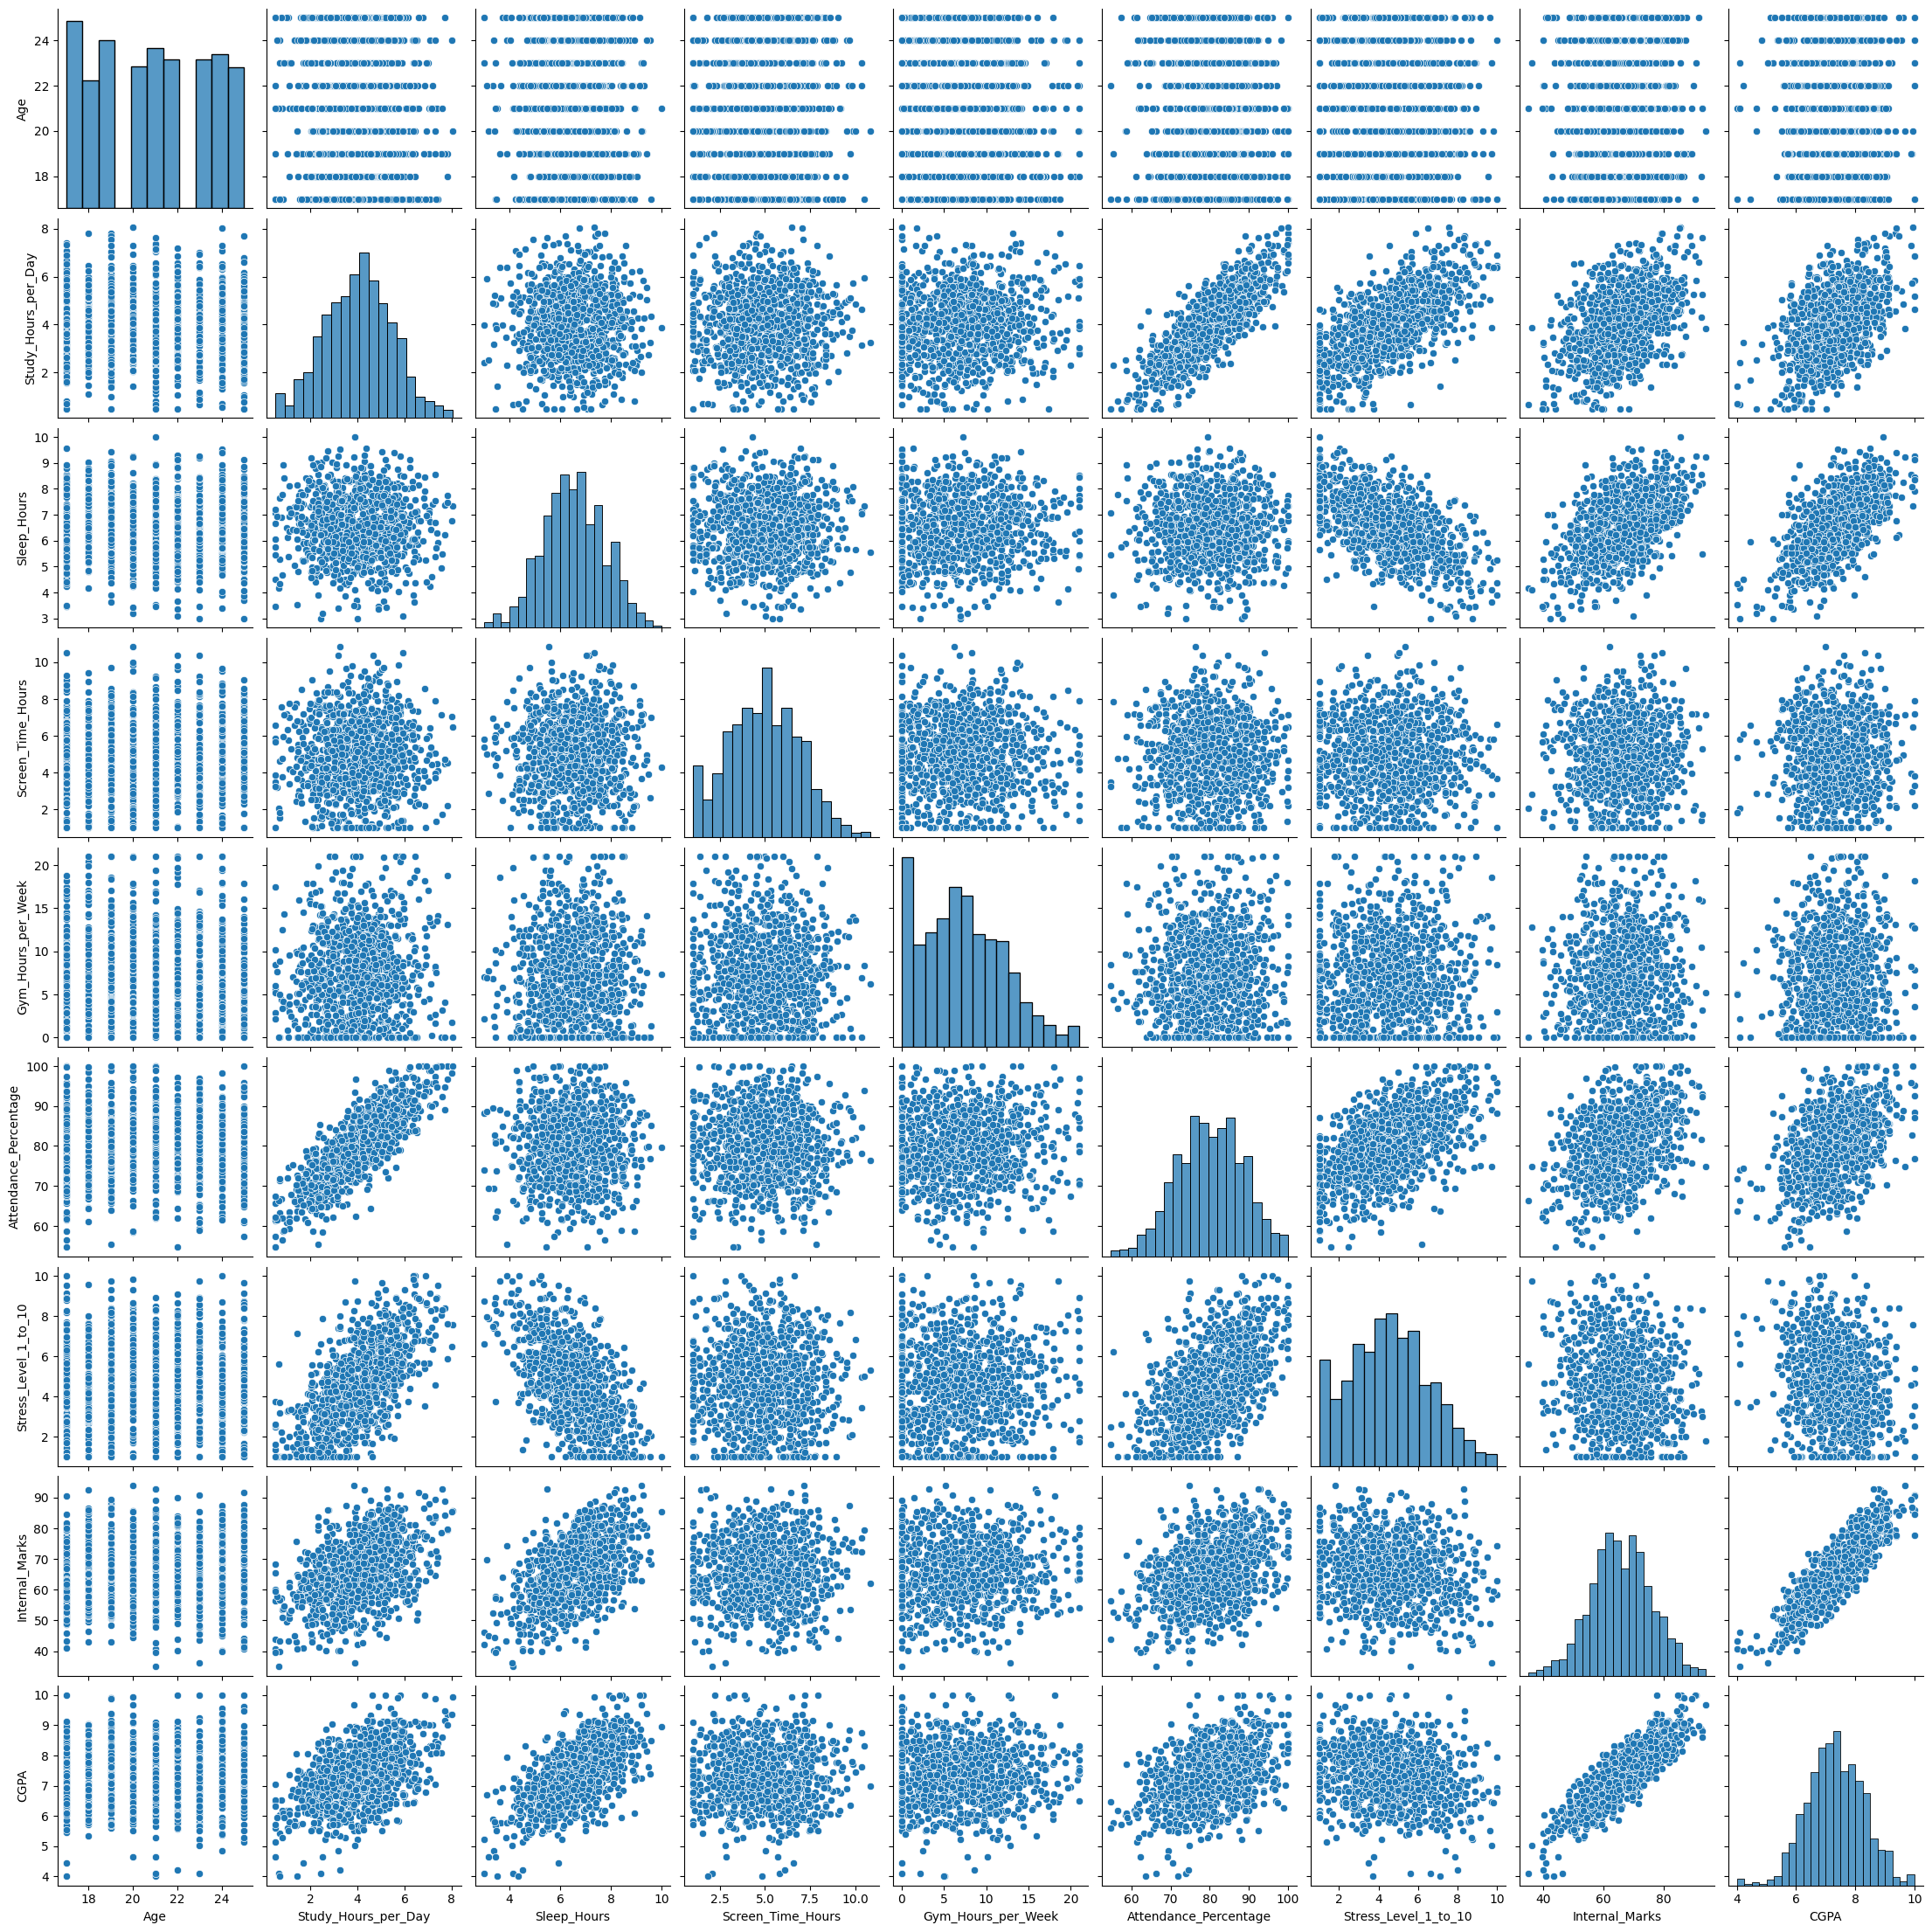

In [7]:
sns.pairplot(df)
plt.show()

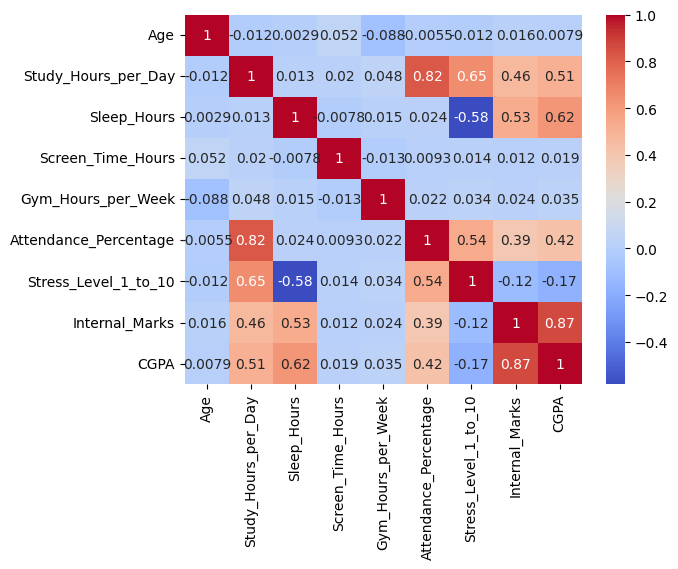

In [8]:
df_list = ["Age","Study_Hours_per_Day","Sleep_Hours","Screen_Time_Hours","Gym_Hours_per_Week","Attendance_Percentage","Stress_Level_1_to_10","Internal_Marks","CGPA"]
sns.heatmap(df[df_list].corr(), annot=True, cmap="coolwarm")
plt.show()

In [9]:
print(df["Branch"].value_counts())
print(df["Diet_Type"].value_counts())
print(df["Residence"].value_counts())

Branch
Civil         177
IT            176
CSE           165
ECE           161
Mechanical    161
Electrical    160
Name: count, dtype: int64
Diet_Type
Veg        593
Non-Veg    407
Name: count, dtype: int64
Residence
Hosteller      503
Day Scholar    497
Name: count, dtype: int64


In [53]:
categorical_cols = ["Branch", "Diet_Type", "Residence"]
numerical_cols = [col for col in df.columns if col not in categorical_cols]
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_data = encoder.fit_transform(df[categorical_cols])
column_transformer = ColumnTransformer(transformers=[('cat', encoder, categorical_cols)],remainder='passthrough')
X_encoded = column_transformer.fit_transform(df)
encoded_col_names = column_transformer.named_transformers_['cat'].get_feature_names_out(categorical_cols)
final_columns = list(encoded_col_names) + numerical_cols
df_encoded = pd.DataFrame(X_encoded, columns=final_columns)
print(df_encoded.head())


   Branch_Civil  Branch_ECE  Branch_Electrical  Branch_IT  Branch_Mechanical  \
0           0.0         1.0                0.0        0.0                0.0   
1           1.0         0.0                0.0        0.0                0.0   
2           0.0         0.0                1.0        0.0                0.0   
3           0.0         0.0                0.0        0.0                0.0   
4           1.0         0.0                0.0        0.0                0.0   

   Diet_Type_Veg  Residence_Hosteller   Age  Study_Hours_per_Day  Sleep_Hours  \
0            0.0                  1.0  23.0                 4.14         6.84   
1            1.0                  0.0  20.0                 5.97         5.52   
2            1.0                  1.0  24.0                 3.19         3.39   
3            0.0                  0.0  21.0                 4.77         6.44   
4            1.0                  0.0  23.0                 5.42         6.54   

   Screen_Time_Hours  Gym_Hours_

In [54]:
df_encoded.describe()

,Branch_Civil,Branch_ECE,Branch_Electrical,Branch_IT,Branch_Mechanical,Diet_Type_Veg,Residence_Hosteller,Age,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Attendance_Percentage,Stress_Level_1_to_10,Internal_Marks,CGPA
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.17700,0.161000,0.160000,0.176000,0.161000,0.593000,0.503000,20.898000,4.037970,6.525030,4.95191,7.311910,80.084340,4.582850,65.922380,7.319300
std,0.38186,0.367715,0.366789,0.381011,0.367715,0.491521,0.500241,2.603916,1.434691,1.205664,1.97294,4.949333,8.578242,2.024595,10.123247,0.953812
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.500000,3.000000,1.00000,0.000000,54.660000,1.000000,35.000000,4.000000
25%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,3.020000,5.710000,3.49000,3.445000,74.307500,3.095000,59.330000,6.690000
50%,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,21.000000,4.090000,6.515000,4.95500,6.975000,80.210000,4.540000,65.600000,7.300000
75%,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,23.000000,5.030000,7.380000,6.37250,10.780000,86.165000,5.962500,72.547500,7.990000
max,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,25.000000,8.050000,10.000000,10.84000,21.000000,100.000000,10.000000,93.930000,10.000000


<Figure size 2000x2000 with 0 Axes>

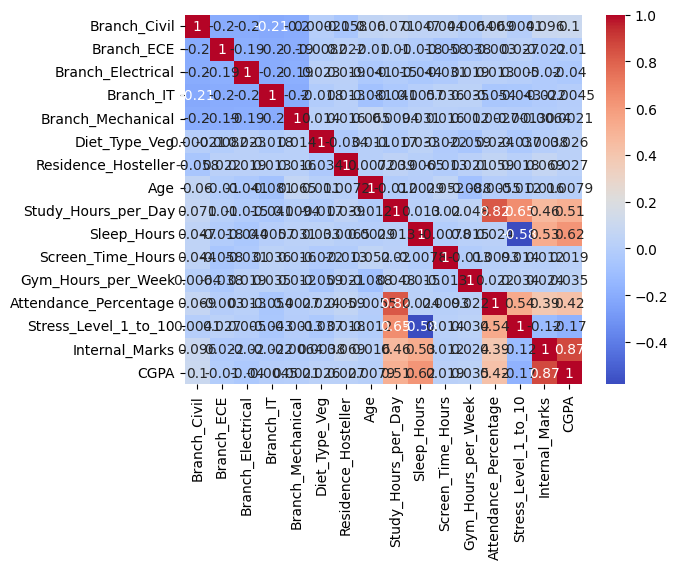

<Figure size 2000x2000 with 0 Axes>

In [76]:
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.figure(figsize=(20, 20))